In [ ]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sn
import zipfile

# 1. Загрузка данных

In [ ]:
import google.colab.drive as drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
path_data_zip = '/content/drive/MyDrive/DFD_Учёба/Домашнее Задание/Data Science в медицине/ПЗ_№1_Анализ медицинских данных/Анализ_мед_данных.zip'

In [ ]:
with zipfile.ZipFile(file=path_data_zip) as data:
  data_list = [file.filename for file in data.filelist]
  print(f' Содержимое zip архива: {data_list}')
  data.extractall()

 Содержимое zip архива: ['adv_bad.csv', 'doctors_base_2021.csv', 'market_ls_16_20.csv', 'prescriptions_16_20.csv', 'promo_16_20.csv']


# 2. Предобработка данных непосредственно в датафреймах

## 2.1 Предобработка и анализ датафрейма: df_adv_bad. РЕКЛАММА

In [ ]:
df_adv_bad = pd.read_csv(filepath_or_buffer='adv_bad.csv', sep=';', encoding='utf-8') # on_bad_lines='skip' если есть битые строки
df_adv_bad.head(1)

,category1,category2,company,brand,date,region,adv_type,adv_type2,amount
0,БИОЛОГИЧЕСКИ АКТИВНЫЕ ДОБАВКИ (БАД),БИОЛОГИЧ. АКТИВ. ДОБ. ДЛЯ ПОХУДЕНИЯ (БАД),PHARMOCEAN LAB,ДОКТОР МОРЕ,01.12.2016,Country level,Magazine,advertising,131659


In [ ]:
# Данные столбца date	конвертирую в тип данных  datetime64[ns] + обработка ошибок метод: errors='coerce'
def preprocessing(df, column_date='date', period='Q'):
  df[column_date] = pd.to_datetime(df[column_date], format='%d.%m.%Y', errors='coerce')
  df['date_Q'] = df[column_date].dt.to_period('Q')
  return df

In [ ]:
# Данные столбца amount	конвертирую в тип данных  float64  + обработка ошибок метод: errors='coerce' т.к присутствуют записи #ЗНАЧ!. Такие значения меняются на NaN
df_adv_bad['amount'] = pd.to_numeric(df_adv_bad['amount'], errors='coerce')

In [ ]:
preprocessing(df_adv_bad).head(3)

,category1,category2,company,brand,date,region,adv_type,adv_type2,amount,date_Q
0,БИОЛОГИЧЕСКИ АКТИВНЫЕ ДОБАВКИ (БАД),БИОЛОГИЧ. АКТИВ. ДОБ. ДЛЯ ПОХУДЕНИЯ (БАД),PHARMOCEAN LAB,ДОКТОР МОРЕ,2016-12-01,Country level,Magazine,advertising,131659.0,2016Q4
1,БИОЛОГИЧЕСКИ АКТИВНЫЕ ДОБАВКИ (БАД),БИОЛОГИЧ. АКТИВ. ДОБ. ДЛЯ ПОХУДЕНИЯ (БАД),PHARMOCEAN LAB,ДОКТОР МОРЕ,2016-12-01,Country level,Magazine,advertising,77849.0,2016Q4
2,БИОЛОГИЧЕСКИ АКТИВНЫЕ ДОБАВКИ (БАД),БИОЛОГИЧ. АКТИВ. ДОБ. ДЛЯ ПОХУДЕНИЯ (БАД),PHARMOCEAN LAB,ДОКТОР МОРЕ,2016-07-01,Country level,Magazine,advertising,37747.0,2016Q3


In [ ]:
df_date_adv_bad = df_adv_bad['date_Q'].value_counts().to_frame().sort_values('date_Q').rename(columns={'count': 'count_adv_bad'})
df_date_adv_bad

,count_adv_bad
date_Q,
2016Q1,1447
2016Q2,681
2016Q3,913
2016Q4,1383
2017Q1,1148
2017Q2,768
2017Q3,735
2017Q4,1174
2018Q1,1393


In [ ]:
# Анализ тип рекламмы. Формирование dataframe. Сортировка
df_adv_type = pd.concat([df_adv_bad['adv_type'].value_counts().to_frame(),
                         df_adv_bad['adv_type2'].value_counts().to_frame()
                         ]).sort_values('count', ascending=False).reset_index().rename(columns={'index': 'adv_type'})
df_adv_type

,adv_type,count
0,video_2,10058
1,TV country_level,5698
2,sponsorship,3861
3,TV sponsors,3322
4,TV regional,3317
5,advertising,1728
6,Magazine,1618
7,Radio,1100
8,Web_Internet,507
9,TV N_Air,482


In [ ]:
# Появляются пропуски в столбце amount т.к первично присутствовали некорректные данные такие как: #ЗНАЧ!
# В датах ошибки не прослеживаются.
df_adv_bad.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16154 entries, 0 to 16153
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   category1  16154 non-null  object        
 1   category2  16154 non-null  object        
 2   company    16154 non-null  object        
 3   brand      16154 non-null  object        
 4   date       16154 non-null  datetime64[ns]
 5   region     16154 non-null  object        
 6   adv_type   16154 non-null  object        
 7   adv_type2  16154 non-null  object        
 8   amount     16129 non-null  float64       
 9   date_Q     16154 non-null  period[Q-DEC] 
dtypes: datetime64[ns](1), float64(1), object(7), period[Q-DEC](1)
memory usage: 1.2+ MB


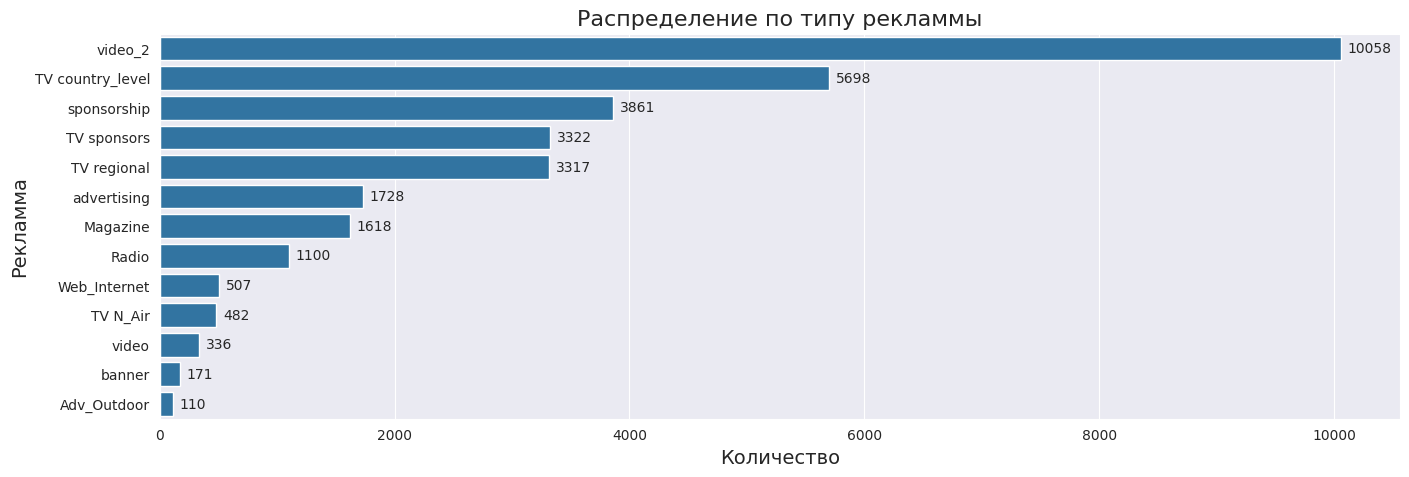

In [ ]:
sn.set_style('darkgrid')
plt.figure(figsize=(16, 5))
ax = sn.barplot(df_adv_type, y='adv_type', x='count')
ax.bar_label(ax.containers[0], padding=5)
plt.title('Распределение по типу рекламмы', size=16)
plt.xlabel('Количество', size=14)
plt.ylabel('Рекламма', size=14)
plt.show()

In [ ]:
# Пропуски в подавляющем большинстве ИММУНОСТИМУЛИРУЮЩИЕ СРЕДСТВА, ГРИППФЕРОН
print(f'Количество пропусков в столбце amount : {df_adv_bad.isnull()['amount'].sum()}')
df_adv_bad[df_adv_bad.isnull().any(axis=1)].head()

Количество пропусков в столбце amount : 25


,category1,category2,company,brand,date,region,adv_type,adv_type2,amount,date_Q
1973,ИММУНОСТИМУЛИРУЮЩИЕ СРЕДСТВА,ИММУНОСТИМУЛИРУЮЩИЕ СРЕДСТВА (РАЗНОЕ),ПОЛИСАН,ЦИКЛОФЕРОН,2017-02-01,Tver,TV regional,video_2,NaN,2017Q1
2309,ИММУНОСТИМУЛИРУЮЩИЕ СРЕДСТВА,ИММУНОСТИМУЛИРУЮЩИЕ СРЕДСТВА (РАЗНОЕ),ФИРН М,ГРИППФЕРОН,2016-08-01,Tula,TV regional,video_2,NaN,2016Q3
2419,ИММУНОСТИМУЛИРУЮЩИЕ СРЕДСТВА,ИММУНОСТИМУЛИРУЮЩИЕ СРЕДСТВА (РАЗНОЕ),ФИРН М,ГРИППФЕРОН,2016-07-01,Perm,TV regional,video_2,NaN,2016Q3
2425,ИММУНОСТИМУЛИРУЮЩИЕ СРЕДСТВА,ИММУНОСТИМУЛИРУЮЩИЕ СРЕДСТВА (РАЗНОЕ),ФИРН М,ГРИППФЕРОН,2016-07-01,Yaroslavl,TV regional,video_2,NaN,2016Q3
2574,ИММУНОСТИМУЛИРУЮЩИЕ СРЕДСТВА,ИММУНОСТИМУЛИРУЮЩИЕ СРЕДСТВА (РАЗНОЕ),ФИРН М,ГРИППФЕРОН,2016-05-01,Tomsk,TV regional,video_2,NaN,2016Q2


In [ ]:
# Статистика столбца amount
df_adv_bad['amount'].describe()

,amount
count,1.612900e+04
mean,1.929762e+06
std,5.203763e+06
min,4.590000e+02
25%,2.728300e+04
50%,1.724150e+05
75%,9.578830e+05
max,7.349087e+07


In [ ]:
# ЗАПОЛНЕНИЕ ПУСТОТ c целью сохранения данных остальных столбцов, но при этом не менять значимо статистику столбца 'amount'
# Замена NaN в amount на среднее значение amount для соответствующей группы (группа определяется комбинацией adv_type2 + adv_type).
df_adv_bad['amount'] = df_adv_bad['amount'].fillna(df_adv_bad.groupby(['adv_type2', 'adv_type'])['amount'].transform('mean'))

In [ ]:
# Статистика после замены
df_adv_bad['amount'].describe()

,amount
count,1.615400e+04
mean,1.926975e+06
std,5.200217e+06
min,4.590000e+02
25%,2.746200e+04
50%,1.718205e+05
75%,9.528608e+05
max,7.349087e+07


In [ ]:
df_adv_bad[df_adv_bad.isnull().any(axis=1)] # пропусков нет

,category1,category2,company,brand,date,region,adv_type,adv_type2,amount,date_Q


## 2.2 Предобработка датафрейма: doctors_base_2021

In [ ]:
df_doctors_base = pd.read_csv('doctors_base_2021.csv', sep=';', encoding='utf-8')

/tmp/ipython-input-1498770680.py:1: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  df_doctors_base = pd.read_csv('doctors_base_2021.csv', sep=';', encoding='utf-8')


In [ ]:
df_doctors_base.head(3)

,type,country,area_old,admin_centre,city,specialty,specialisation,amount,area,date
0,дополнительная специальность,Азербайджан,Апшеронский,NaN,Хырдалан,Венерология,Венерология (поликлиника),3.0,NaN,01.01.2021
1,дополнительная специальность,Азербайджан,Баку,NaN,Амирджаны,Детская венерология,Детская венерология (стационар),1.0,NaN,01.01.2021
2,дополнительная специальность,Азербайджан,Баку,NaN,Бакиханов,Венерология,Венерология (поликлиника),2.0,NaN,01.01.2021


In [ ]:
preprocessing(df_doctors_base).head(3)

,type,country,area_old,admin_centre,city,specialty,specialisation,amount,area,date,date_Q
0,дополнительная специальность,Азербайджан,Апшеронский,NaN,Хырдалан,Венерология,Венерология (поликлиника),3.0,NaN,2021-01-01,2021Q1
1,дополнительная специальность,Азербайджан,Баку,NaN,Амирджаны,Детская венерология,Детская венерология (стационар),1.0,NaN,2021-01-01,2021Q1
2,дополнительная специальность,Азербайджан,Баку,NaN,Бакиханов,Венерология,Венерология (поликлиника),2.0,NaN,2021-01-01,2021Q1


In [ ]:
df_date_doctors_base = df_doctors_base['date_Q'].value_counts().to_frame().sort_values('date_Q').rename(columns={'count':'count_doctors_base'})
df_date_doctors_base

,count_doctors_base
date_Q,
2021Q1,165209
2021Q2,165209
2021Q4,165209


In [ ]:
df_doctors_base.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 495627 entries, 0 to 495626
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   type            495627 non-null  object        
 1   country         495627 non-null  object        
 2   area_old        495627 non-null  object        
 3   admin_centre    468948 non-null  object        
 4   city            495627 non-null  object        
 5   specialty       495627 non-null  object        
 6   specialisation  495627 non-null  object        
 7   amount          495627 non-null  float64       
 8   area            284193 non-null  object        
 9   date            495627 non-null  datetime64[ns]
 10  date_Q          495627 non-null  period[Q-DEC] 
dtypes: datetime64[ns](1), float64(1), object(8), period[Q-DEC](1)
memory usage: 41.6+ MB


In [ ]:
# очень много пропусков в столбцах: admin_centre и area
df_doctors_base.isnull().sum()

,0
type,0
country,0
area_old,0
admin_centre,26679
city,0
specialty,0
specialisation,0
amount,0
area,211434
date,0


In [ ]:
df_doctors_base.columns.to_numpy()

array(['type', 'country', 'area_old', 'admin_centre', 'city', 'specialty',
       'specialisation', 'amount', 'area', 'date', 'date_Q'], dtype=object)

In [ ]:
df_top_10_specialty = df_doctors_base.groupby(['specialty'])['amount'].sum().sort_values(ascending=False).head(10).to_frame().reset_index()
df_top_10_specialty

,specialty,amount
0,Терапия,420681.0
1,Фармацевт,322374.0
2,Провизор,316869.0
3,Педиатрия,268593.0
4,Акушерство и гинекология,241869.0
5,Организация и управление здравоохранением,161025.0
6,Неврология,130908.0
7,Хирургия общая,130518.0
8,Общая практика - семейная медицина,129120.0
9,Кардиология,104748.0


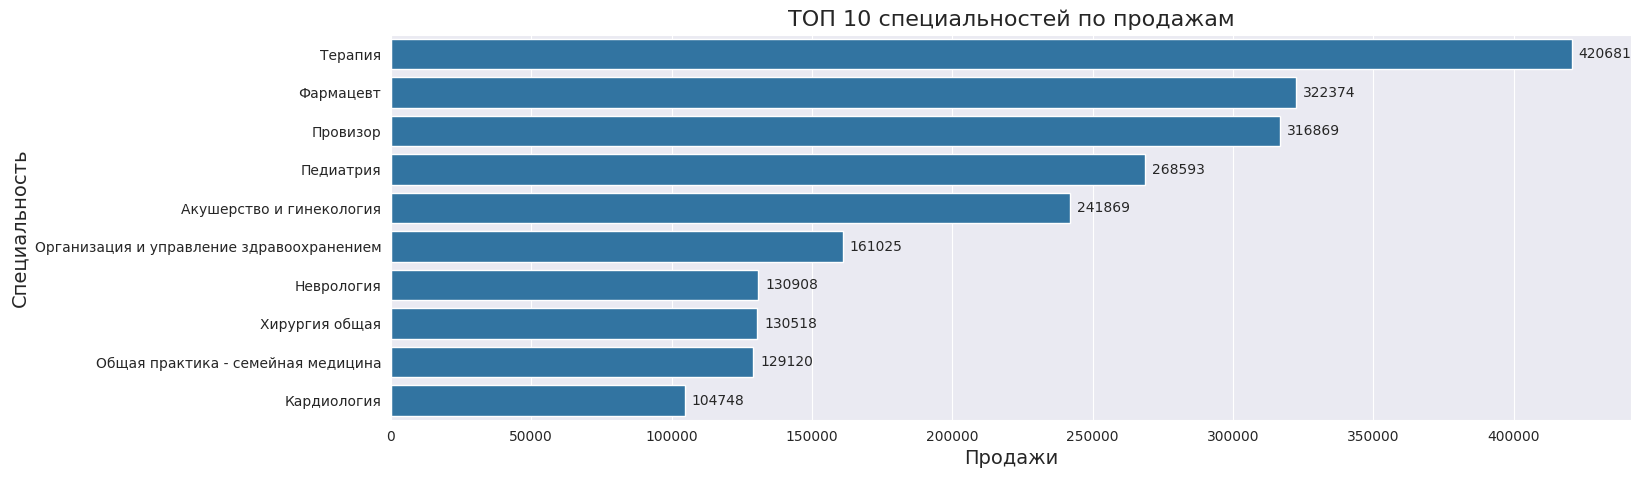

In [ ]:
sn.set_style('darkgrid')
plt.figure(figsize=(16, 5))
ax = sn.barplot(df_top_10_specialty, y='specialty', x='amount')
ax.bar_label(ax.containers[0], padding=5)
plt.title('ТОП 10 специальностей по продажам', size=16)
plt.xlabel('Продажи', size=14)
plt.ylabel('Специальность', size=14)
plt.show()

In [ ]:
# Соотношение по специальностям
df_proportion_type = df_doctors_base['type'].value_counts(normalize=True).to_frame().reset_index()
df_proportion_type

,type,proportion
0,основная специальность,0.653857
1,дополнительная специальность,0.346143


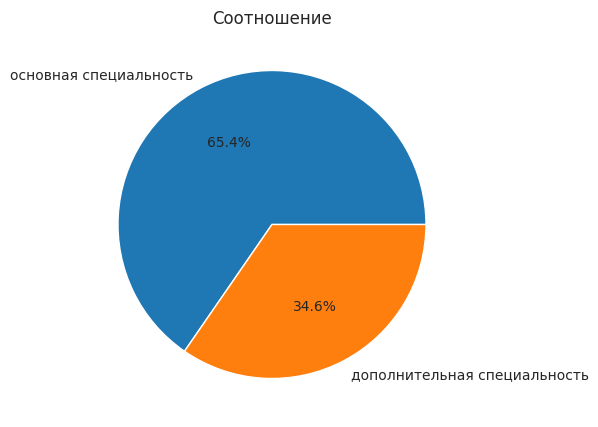

In [ ]:
plt.figure(figsize=(5, 5))
plt.pie(df_proportion_type['proportion'], labels=df_proportion_type['type'], autopct='%1.1f%%')
plt.title('Соотношение')
plt.show()


In [ ]:
# Топ 10 по городам
df_doctors_base.groupby(['city'])['amount'].sum().sort_values(ascending=False).head(10)

,amount
city,
Москва,355476.0
Санкт-Петербург,156027.0
Киев,148767.0
Харьков,64164.0
Минск,48558.0
Алматы,48255.0
Одесса,47982.0
Новосибирск,47253.0
Екатеринбург,46032.0


## 2.3 Предобработка датафрейма: market_ls_16_20

In [ ]:
df_market_ls = pd.read_csv('market_ls_16_20.csv', sep=';', encoding='utf-8')

In [ ]:
df_market_ls.head(3)

,date,brand,Rx/OTC,sales_packs
0,01.09.2017,БАКЛОСАН,Rx,83890
1,01.03.2017,ЦЕФОПЕРАЗОН,Rx,537
2,01.04.2019,ФИТОФРОН,OTC,17562


In [ ]:
preprocessing(df_market_ls).head()

,date,brand,Rx/OTC,sales_packs,date_Q
0,2017-09-01,БАКЛОСАН,Rx,83890,2017Q3
1,2017-03-01,ЦЕФОПЕРАЗОН,Rx,537,2017Q1
2,2019-04-01,ФИТОФРОН,OTC,17562,2019Q2
3,2016-02-01,ИВЕПРЕД,Rx,360,2016Q1
4,2017-10-01,ПАНТЕНОЛ,OTC,52088,2017Q4


In [ ]:
df_date_market_sales = df_market_ls['date_Q'].value_counts().to_frame().sort_values('date_Q').rename(columns={'count': 'count_market_sales'})
df_date_market_sales

,count_market_sales
date_Q,
2016Q1,13385
2016Q2,13460
2016Q3,13738
2016Q4,13895
2017Q1,13916
2017Q2,13770
2017Q3,13859
2017Q4,13786
2018Q1,13789


## 2.4 Предобработка датафрейма: prescriptions

In [ ]:
df_prescriptions = pd.read_csv('prescriptions_16_20.csv', sep=';', encoding='utf-8')

In [ ]:
df_prescriptions.head(3)

,date,brand,specialty,rx_otc,mnn,atc1_name,amount
0,01.01.2016,5-НОК,pediatr,Rx,НИТРОКСОЛИН,J ПРОТИВОМИКРОБНЫЕ СРЕДСТВА ДЛЯ СИСТЕМНОГО ПРИ...,509
1,01.01.2016,5-НОК,terapevt_vop,Rx,НИТРОКСОЛИН,J ПРОТИВОМИКРОБНЫЕ СРЕДСТВА ДЛЯ СИСТЕМНОГО ПРИ...,545
2,01.01.2016,5-НОК,urolog,Rx,НИТРОКСОЛИН,J ПРОТИВОМИКРОБНЫЕ СРЕДСТВА ДЛЯ СИСТЕМНОГО ПРИ...,8548


In [ ]:
df_prescriptions['amount'] = pd.to_numeric(df_prescriptions['amount'], errors='coerce')

In [ ]:
preprocessing(df_prescriptions).head()

,date,brand,specialty,rx_otc,mnn,atc1_name,amount,date_Q
0,2016-01-01,5-НОК,pediatr,Rx,НИТРОКСОЛИН,J ПРОТИВОМИКРОБНЫЕ СРЕДСТВА ДЛЯ СИСТЕМНОГО ПРИ...,509,2016Q1
1,2016-01-01,5-НОК,terapevt_vop,Rx,НИТРОКСОЛИН,J ПРОТИВОМИКРОБНЫЕ СРЕДСТВА ДЛЯ СИСТЕМНОГО ПРИ...,545,2016Q1
2,2016-01-01,5-НОК,urolog,Rx,НИТРОКСОЛИН,J ПРОТИВОМИКРОБНЫЕ СРЕДСТВА ДЛЯ СИСТЕМНОГО ПРИ...,8548,2016Q1
3,2016-01-01,5-ФТОРУРАЦИЛ,terapevt_vop,Rx,ФЛУОРОУРАЦИЛ,L АНТИНЕОПЛАСТИЧЕСКИЕ И ИММУНОМОДУЛИРУЮЩИЕ СРЕ...,532,2016Q1
4,2016-01-01,L-АСПАРАГИНАЗА,allergolor_pulmonolog,Rx,АСПАРАГИНАЗА*,L АНТИНЕОПЛАСТИЧЕСКИЕ И ИММУНОМОДУЛИРУЮЩИЕ СРЕ...,493,2016Q1


In [ ]:
df_prescriptions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105196 entries, 0 to 105195
Data columns (total 8 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   date       105196 non-null  datetime64[ns]
 1   brand      105196 non-null  object        
 2   specialty  105196 non-null  object        
 3   rx_otc     83179 non-null   object        
 4   mnn        105196 non-null  object        
 5   atc1_name  105178 non-null  object        
 6   amount     105196 non-null  int64         
 7   date_Q     105196 non-null  period[Q-DEC] 
dtypes: datetime64[ns](1), int64(1), object(5), period[Q-DEC](1)
memory usage: 6.4+ MB


In [ ]:
df_date_prescriptions = df_prescriptions['date_Q'].value_counts().to_frame().sort_values('date_Q').rename(columns={'count': 'count_prescriptions'})
print(len(df_date_prescriptions))
df_date_prescriptions

19


,count_prescriptions
date_Q,
2016Q1,6057
2016Q2,5866
2016Q3,5808
2016Q4,5793
2017Q1,5806
2017Q2,5777
2017Q3,5405
2017Q4,5447
2018Q1,5366


In [ ]:
# Рецепты по брендам
prescriptions_brand = df_prescriptions.groupby('brand')['amount'].sum('amount').to_frame().reset_index().sort_values('amount', ascending=False)
print(prescriptions_brand.index.max())
prescriptions_brand.head()

5106


,brand,amount
1647,ИНГАВИРИН,22279439
2605,МИДОКАЛМ,21349561
2739,НАЗИВИН,17577712
2492,МЕКСИДОЛ,17346209
2588,МЕТФОРМИН,16291903


In [ ]:
df_prescriptions.groupby('specialty')['amount'].sum('amount').to_frame().reset_index()

,specialty,amount
0,allergolor_pulmonolog,33633651
1,endokrinolog,64878870
2,gastroentorolog,61084705
3,neurolog,190744993
4,otolaringolog,97311087
5,pediatr,343527735
6,terapevt_vop,811559368
7,urolog,56758539


In [ ]:
df_prescriptions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105196 entries, 0 to 105195
Data columns (total 8 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   date       105196 non-null  datetime64[ns]
 1   brand      105196 non-null  object        
 2   specialty  105196 non-null  object        
 3   rx_otc     83179 non-null   object        
 4   mnn        105196 non-null  object        
 5   atc1_name  105178 non-null  object        
 6   amount     105196 non-null  int64         
 7   date_Q     105196 non-null  period[Q-DEC] 
dtypes: datetime64[ns](1), int64(1), object(5), period[Q-DEC](1)
memory usage: 6.4+ MB


## 2.5 Предобработка датафрейма: promo

In [ ]:
df_promo = pd.read_csv('promo_16_20.csv', sep=';', encoding='utf-8')

In [ ]:
df_promo.head(3)

,date,brand,promotion,speciality,rx_otc,mnn,atc1_name,amount
0,01.01.2016,АЗИДРОП,reps_visits,otolaringolog,Rx,АЗИТРОМИЦИН,"S СРЕДСТВА, ДЕЙСТВУЮЩИЕ НА ОРГАНЫ ЧУВСТВ",115
1,01.01.2016,АЗИМИЦИН,reps_visits,terapevt_vop,Rx,АЗИТРОМИЦИН,J ПРОТИВОМИКРОБНЫЕ СРЕДСТВА ДЛЯ СИСТЕМНОГО ПРИ...,115
2,01.01.2016,АЗИТРОМИЦИН ЗЕНТ,reps_visits,otolaringolog,Rx,АЗИТРОМИЦИН,J ПРОТИВОМИКРОБНЫЕ СРЕДСТВА ДЛЯ СИСТЕМНОГО ПРИ...,115


In [ ]:
preprocessing(df_promo).head(3)

,date,brand,promotion,speciality,rx_otc,mnn,atc1_name,amount,date_Q
0,2016-01-01,АЗИДРОП,reps_visits,otolaringolog,Rx,АЗИТРОМИЦИН,"S СРЕДСТВА, ДЕЙСТВУЮЩИЕ НА ОРГАНЫ ЧУВСТВ",115,2016Q1
1,2016-01-01,АЗИМИЦИН,reps_visits,terapevt_vop,Rx,АЗИТРОМИЦИН,J ПРОТИВОМИКРОБНЫЕ СРЕДСТВА ДЛЯ СИСТЕМНОГО ПРИ...,115,2016Q1
2,2016-01-01,АЗИТРОМИЦИН ЗЕНТ,reps_visits,otolaringolog,Rx,АЗИТРОМИЦИН,J ПРОТИВОМИКРОБНЫЕ СРЕДСТВА ДЛЯ СИСТЕМНОГО ПРИ...,115,2016Q1


In [ ]:
df_data_promo = df_promo['date_Q'].value_counts().sort_values().to_frame().sort_values('date_Q').rename(columns={'count': 'count_promo'})
print(len(df_data_promo))
df_data_promo

19


,count_promo
date_Q,
2016Q1,9845
2016Q2,10195
2016Q3,8932
2016Q4,9732
2017Q1,9970
2017Q2,10213
2017Q3,9802
2017Q4,11023
2018Q1,10787


In [ ]:
df_promo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 272200 entries, 0 to 272199
Data columns (total 9 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   date        272200 non-null  datetime64[ns]
 1   brand       272200 non-null  object        
 2   promotion   272200 non-null  object        
 3   speciality  272200 non-null  object        
 4   rx_otc      199301 non-null  object        
 5   mnn         272200 non-null  object        
 6   atc1_name   271243 non-null  object        
 7   amount      272200 non-null  int64         
 8   date_Q      272200 non-null  period[Q-DEC] 
dtypes: datetime64[ns](1), int64(1), object(6), period[Q-DEC](1)
memory usage: 18.7+ MB


In [ ]:
promo_brand = df_promo.groupby('brand')['amount'].sum('amount').to_frame().reset_index().sort_values('amount', ascending=False)
print(promo_brand.index.max())
promo_brand.head()

4848


,brand,amount
3897,ТЕРАФЛЮ,1924007
350,АРБИДОЛ,1440104
1542,ИНГАВИРИН,1403457
1643,КАГОЦЕЛ,1193398
957,ГЕКСОРАЛ,1131900


## ИТОГОВАЯ ТАБЛИЦА, КОТОРАЯ ХАРАКТЕРЕЗУЕТ КАКИЕ ДАТЫ ЕСТЬ В ДАТАФРЕЙМАХ

In [ ]:
# ИТОГОВАЯ ТАБЛИЦА, КОТОРАЯ ХАРАКТЕРЕЗУЕТ КАКИЕ ДАТЫ ЕСТЬ ДАТАФРЕЙМАХ. Значение в таблицах указывает количество (count) соотвествующих дат.
# В таблице doctors_base определяются только даты первого квартала 2021 года, которых нет во всех остальных 4 таблицах.
# Из данной таблице объединение по датам целесообразно только с первого квартала 2016 года по 2 квартал 2020г. Остальные данные по датам будут с пропусками!
df_full_date = (df_date_market_sales.merge(right=df_date_prescriptions, how='left', on='date_Q')
                .merge(right=df_data_promo, how='left', on='date_Q')
                .merge(right=df_date_adv_bad, how='left', on= 'date_Q')
                .merge(right=df_date_doctors_base, how='outer', on='date_Q')).reset_index()

df_full_date

,date_Q,count_market_sales,count_prescriptions,count_promo,count_adv_bad,count_doctors_base
0,2016Q1,13385.0,6057.0,9845.0,1447.0,NaN
1,2016Q2,13460.0,5866.0,10195.0,681.0,NaN
2,2016Q3,13738.0,5808.0,8932.0,913.0,NaN
3,2016Q4,13895.0,5793.0,9732.0,1383.0,NaN
4,2017Q1,13916.0,5806.0,9970.0,1148.0,NaN
5,2017Q2,13770.0,5777.0,10213.0,768.0,NaN
6,2017Q3,13859.0,5405.0,9802.0,735.0,NaN
7,2017Q4,13786.0,5447.0,11023.0,1174.0,NaN
8,2018Q1,13789.0,5366.0,10787.0,1393.0,NaN
9,2018Q2,13681.0,5367.0,13073.0,590.0,NaN


## СТОЛБЦЫ

In [ ]:
df_adv_bad.head(1)

,category1,category2,company,brand,date,region,adv_type,adv_type2,amount,date_Q
0,БИОЛОГИЧЕСКИ АКТИВНЫЕ ДОБАВКИ (БАД),БИОЛОГИЧ. АКТИВ. ДОБ. ДЛЯ ПОХУДЕНИЯ (БАД),PHARMOCEAN LAB,ДОКТОР МОРЕ,2016-12-01,Country level,Magazine,advertising,131659.0,2016Q4


In [ ]:
df_doctors_base.head(1)

,type,country,area_old,admin_centre,city,specialty,specialisation,amount,area,date,date_Q
0,дополнительная специальность,Азербайджан,Апшеронский,NaN,Хырдалан,Венерология,Венерология (поликлиника),3.0,NaN,2021-01-01,2021Q1


In [ ]:
df_promo.head(1)

,date,brand,promotion,speciality,rx_otc,mnn,atc1_name,amount,date_Q
0,2016-01-01,АЗИДРОП,reps_visits,otolaringolog,Rx,АЗИТРОМИЦИН,"S СРЕДСТВА, ДЕЙСТВУЮЩИЕ НА ОРГАНЫ ЧУВСТВ",115,2016Q1


In [ ]:
df_prescriptions.head(1)

,date,brand,specialty,rx_otc,mnn,atc1_name,amount,date_Q
0,2016-01-01,5-НОК,pediatr,Rx,НИТРОКСОЛИН,J ПРОТИВОМИКРОБНЫЕ СРЕДСТВА ДЛЯ СИСТЕМНОГО ПРИ...,509,2016Q1


In [ ]:
df_market_ls.head(1)

,date,brand,Rx/OTC,sales_packs,date_Q
0,2017-09-01,БАКЛОСАН,Rx,83890,2017Q3


In [ ]:
df_market_ls = df_market_ls.rename(columns={'sales_packs': 'amount', 'Rx/OTC': 'rx_otc'})
df_market_ls.head(3)

,date,brand,rx_otc,amount,date_Q
0,2017-09-01,БАКЛОСАН,Rx,83890,2017Q3
1,2017-03-01,ЦЕФОПЕРАЗОН,Rx,537,2017Q1
2,2019-04-01,ФИТОФРОН,OTC,17562,2019Q2


In [ ]:
categ_adv = df_adv_bad.groupby('category1')['amount'].sum().to_frame().sort_values('amount', ascending=False)
print(len(categ_adv))
categ_adv.head(3)

82


,amount
category1,
ИММУНОСТИМУЛИРУЮЩИЕ СРЕДСТВА,5.511213e+09
СРЕДСТВА ОТ ПРОСТУДЫ И ГРИППА,5.355289e+09
ПСИХОТРОПНЫЕ И НЕВРОЛОГИЧЕСКИЕ СРЕДСТВА,3.853758e+09


In [ ]:
categ_promo = df_promo.groupby('atc1_name')['amount'].sum().to_frame().sort_values('amount', ascending=False)
print(len(categ_promo))
categ_promo.head(3)

14


,amount
atc1_name,
"A СРЕДСТВА, ВЛИЯЮЩИЕ НА ПИЩЕВАРИТЕЛЬНУЮ СИСТЕМУ И МЕТАБОЛИЗМ",35195651
"R СРЕДСТВА, ДЕЙСТВУЮЩИЕ НА РЕСПИРАТОРНУЮ СИСТЕМУ",26005722
"C СРЕДСТВА, ВЛИЯЮЩИЕ НА СЕРДЕЧНО-СОСУДИСТУЮ СИСТЕМУ",20836366


In [ ]:
categ_prescriptions = df_prescriptions.groupby('atc1_name')['amount'].sum().to_frame().sort_values('amount', ascending=False)
print(len(categ_prescriptions))
categ_prescriptions.head(3)

15


,amount
atc1_name,
"A СРЕДСТВА, ВЛИЯЮЩИЕ НА ПИЩЕВАРИТЕЛЬНУЮ СИСТЕМУ И МЕТАБОЛИЗМ",356630836
"R СРЕДСТВА, ДЕЙСТВУЮЩИЕ НА РЕСПИРАТОРНУЮ СИСТЕМУ",337819151
"C СРЕДСТВА, ВЛИЯЮЩИЕ НА СЕРДЕЧНО-СОСУДИСТУЮ СИСТЕМУ",245261891


## Функция которая анализирует корреляцию между N датафреймами по заданной группировке.

In [ ]:
def analyze_correlation_multi(
    dfs,                   # список датафреймов
    group_col,             # столбец для группировки (например, 'atc1_name')
    value_col,             # столбец с значениями для суммирования (например, 'amount')
    df_names=None,         # список имён для датафреймов (если None — возьмёт индексы)
    plot=True,             # строить ли график
    corr_method='pearson', # метод корреляции: 'pearson', 'spearman', 'kendall'
    figsize=(12, 4),        # размер графика
    title=None             # заголовок графика (если None — сгенерирует автоматически)
):
    """
    Анализирует корреляцию между N датафреймами по заданной группировке.

    Параметры:
    -----------
    dfs : list of pd.DataFrame
        Список датафреймов для анализа
    group_col : str
        Название столбца для группировки
    value_col : str
        Название столбца с числовыми значениями для суммирования
    df_names : list of str, optional
        Имена для датафреймов в итоговом датафрейме (по умолчанию: ['df0', 'df1', ...])
    plot : bool
        Показывать ли график (по умолчанию True)
    corr_method : str
        Метод корреляции: 'pearson' (по умолчанию), 'spearman', 'kendall'
    figsize : tuple
        Размер графика (ширина, высота)
    title : str, optional
        Заголовок графика (если None — будет сгенерирован)

    Возвращает:
    ------------
    pd.DataFrame
        Датафрейм с суммами по группам и результатами корреляции
    """

    # Проверки
    if len(dfs) < 2:
        raise ValueError("Нужно минимум 2 датафрейма для анализа корреляции.")

    if df_names is None:
        df_names = [f'df{i}' for i in range(len(dfs))]
    elif len(df_names) != len(dfs):
        raise ValueError("Длина df_names должна совпадать с количеством датафреймов.")

    # Шаг 1. Группируем каждый датафрейм и суммируем value_col
    grouped_list = []
    for i, df in enumerate(dfs):
        grouped = (
            df.groupby(group_col)[value_col]
            .sum()
            .to_frame()
            .sort_values(value_col, ascending=False)
        )
        grouped.columns = [f'sum_{value_col}_{df_names[i]}']
        grouped_list.append(grouped)

    # Шаг 2. Сливаем все датафреймы по group_col
    merged = grouped_list[0]
    for i in range(1, len(grouped_list)):
        merged = merged.merge(
            grouped_list[i],
            how='inner',  # 'outer' — чтобы не терять группы, отсутствующие в каких‑то датафреймах
            on=group_col
        )

    # Шаг 3. Вычисляем корреляцию
    corr_matrix = merged.corr(method=corr_method)
    print("Матрица корреляции:")
    #print(corr_matrix)

    # Шаг 4. Строим график (если нужно)
    if plot:
        if title is None:
            title = f'Корреляция между {", ".join(df_names)} по {group_col}'

        plt.figure(figsize=figsize)
        sn.heatmap(
            corr_matrix,
            annot=True,
            cmap='RdYlGn', #cmap='coolwarm'
            vmin=-1, vmax=1,
            linewidths=0.5,
            fmt='.2f'
        )
        plt.title(title, fontsize=12)
        plt.tight_layout()
        plt.show()

    return merged

## КОРРЕЛЯЦИИ

Матрица корреляции:


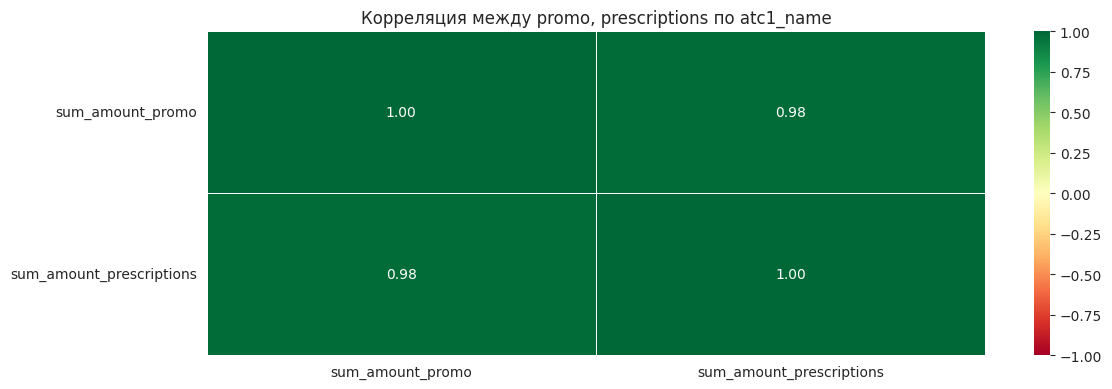

In [ ]:
result = analyze_correlation_multi(
    dfs=[df_promo, df_prescriptions],
    group_col='atc1_name',
    value_col='amount',
    df_names=['promo', 'prescriptions'],
    plot=True,
    corr_method='pearson'
)

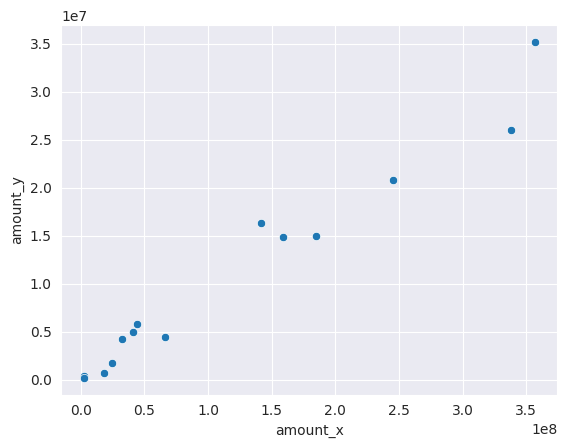

In [ ]:
df_corr = categ_prescriptions.merge(right=categ_promo, how='left', on='atc1_name')
sn.scatterplot(df_corr, x='amount_x', y='amount_y');

Матрица корреляции:


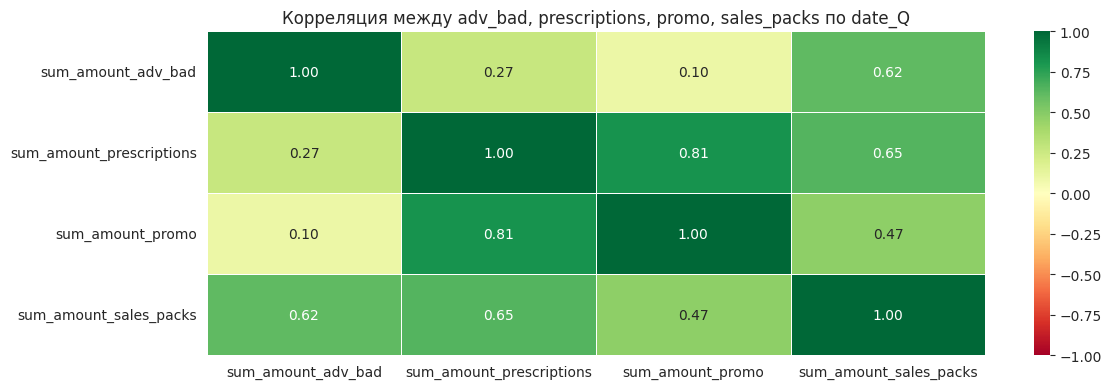

In [ ]:
result_date_amount = analyze_correlation_multi(
    dfs=[df_adv_bad, df_prescriptions, df_promo, df_market_ls],
    group_col = 'date_Q',
    value_col='amount',
    df_names=['adv_bad', 'prescriptions', 'promo', 'sales_packs'],
    plot=True,
    corr_method='pearson'
)

Матрица корреляции:


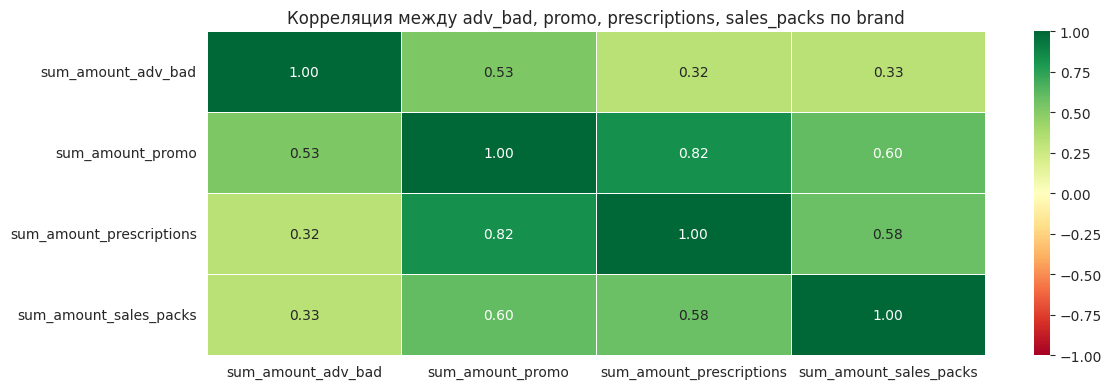

In [ ]:
result_brand = analyze_correlation_multi(
    dfs=[df_adv_bad, df_promo, df_prescriptions, df_market_ls],
    group_col='brand',
    value_col='amount',
    df_names=['adv_bad', 'promo', 'prescriptions', 'sales_packs'],
    plot=True,
    corr_method='pearson' #'spearman'
)

Матрица корреляции:


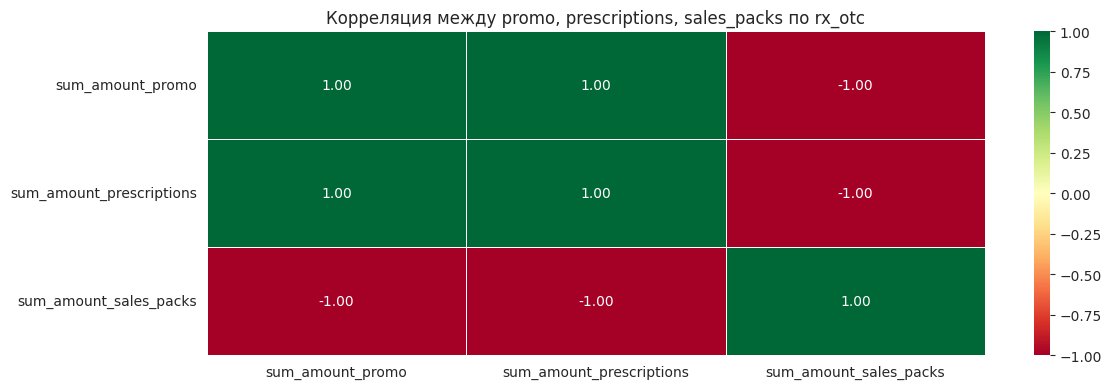

In [ ]:
result_rx_otc = analyze_correlation_multi(
    dfs=[df_promo, df_prescriptions, df_market_ls],
    group_col='rx_otc',
    value_col='amount',
    df_names=['promo', 'prescriptions', 'sales_packs'],
    plot=True,
    corr_method='pearson'
)

## MERGE. По БРЕНДУ

In [ ]:
df_brand_adv = df_adv_bad.groupby('brand')['amount'].sum().to_frame().rename(columns={'amount': 'amount'+'_adv'})
#print(df_brand_adv['brand'].nunique())

In [ ]:
df_brand_promo = df_promo.groupby('brand')['amount'].sum().to_frame().rename(columns={'amount': 'amount'+'_promo'})
#print(df_brand_promo['brand'].nunique())

In [ ]:
df_brand_prescriptions = df_prescriptions.groupby('brand')['amount'].sum().to_frame().rename(columns={'amount': 'amount'+'_prescriptions'})
#print(df_brand_prescriptions['brand'].nunique())

In [ ]:
df_brand_market = df_market_ls.groupby('brand')['amount'].sum().to_frame().rename(columns={'amount': 'sales_packs'})

In [ ]:
df_merge = (df_brand_market.merge(right=df_brand_prescriptions, on='brand', how='inner')
            .merge(right=df_brand_promo, on='brand', how='inner')
            .merge(right=df_brand_adv, on='brand', how='inner')
    ).reset_index()

In [ ]:
print(len(df_merge))
df_merge.head(10)

56


,brand,sales_packs,amount_prescriptions,amount_promo,amount_adv
0,АМБРОБЕНЕ,48382516,7139811,612426,4.490941e+08
1,АМИКСИН,13811351,1123151,319388,1.519902e+08
2,АНАФЕРОН,9140644,4942809,636440,1.344578e+08
3,АРБИДОЛ,102035730,13678244,1440104,5.873944e+08
4,АФАЛА,1809106,164045,54865,2.103532e+07
5,АФАЛАЗА,2278399,363073,129611,2.981877e+08
6,АФОБАЗОЛ,33082449,738333,210024,1.289164e+09
7,АЦЦ,80917386,9493648,518876,2.983269e+08
8,БРОНХИПРЕТ,5080907,1172001,415272,1.339486e+06
9,БРОНХО-МУНАЛ,21512187,3312297,341527,1.238497e+09


# Построение модели

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()

In [ ]:
X = df_merge[['amount_prescriptions', 'amount_promo', 'amount_adv']]
target = df_merge['sales_packs']

In [ ]:
X_scaler = scaler.fit_transform(X)

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(X_scaler, target, train_size=0.8, random_state=1982)

In [ ]:
model_linearReg = LinearRegression()

In [ ]:
model_linearReg.fit(x_train, y_train)

LinearRegression()

In [ ]:
poly = PolynomialFeatures(degree=2, include_bias=False)

In [ ]:
X_train_poly = poly.fit_transform(x_train)
X_test_poly = poly.transform(x_test)

In [ ]:
model_poly = LinearRegression()
model_poly.fit(X_train_poly, y_train)

LinearRegression()

In [ ]:
model_tree = DecisionTreeRegressor(random_state=1982, max_depth=3)

In [ ]:
model_tree.fit(x_train, y_train)

DecisionTreeRegressor(max_depth=3, random_state=1982)

In [ ]:
def metrics_(model):
  y_pred_train = model.predict(x_train)
  y_pred_test = model.predict(x_test)

  mse_train = mean_squared_error(y_train, y_pred_train)
  mae_train = mean_absolute_error(y_train, y_pred_train)
  r2_train = r2_score(y_train, y_pred_train)

  mse_test = mean_squared_error(y_test, y_pred_test)
  mae_test = mean_absolute_error(y_test, y_pred_test)
  r2_test = r2_score(y_test, y_pred_test)

  df_metrics_y_test = pd.DataFrame({'MAE': mae_test, 'MSE': mse_test, 'R2': r2_test}, index=['x_test'])

  df_metrics_y_train = pd.DataFrame({'MAE': mae_train, 'MSE': mse_train, 'R2': r2_train}, index=['x_train'])

  return pd.concat([df_metrics_y_train, df_metrics_y_test], axis=0)

In [ ]:
# Дерево решений
metrics_(model_tree)

,MAE,MSE,R2
x_train,5.361314e+06,6.296066e+13,0.863908
x_test,2.496894e+07,1.717672e+15,-0.190635


In [ ]:
# Линейная регрессия
metrics_(model_linearReg)

,MAE,MSE,R2
x_train,8.760197e+06,1.320894e+14,0.714484
x_test,2.165570e+07,1.530489e+15,-0.060886


In [ ]:
# полиномиальная регрессия
#X_train_poly
#X_test_poly

y_pred_test = model_poly.predict(X_test_poly)

mse = mean_squared_error(y_test, y_pred_test)

mae = mean_absolute_error(y_test, y_pred_test)

r2 = r2_score(y_test, y_pred_test)

print(f"MSE_test: {mse:.4f}")
print(f"MAE_test: {mae:.4f}")
print(f'R²_test: {r2:.4f}')


MSE_test: 1430653582069923.2500
MAE_test: 21622969.9881
R²_test: 0.0083
